# Projeto Redes Neurais

In [ ]:
import matplotlib.pyplot as plt
import mlx.core as mx
import mlx.nn as mnn
import mlx.optimizers as optim
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
from xgboost import XGBClassifier

RANDOM_STATE = 42
N_SPLITS = 5


## Dados

In [62]:
def preencher_nulos_knn_onehot(df, n_vizinhos=5):
    """
    Preenche valores nulos em um DataFrame misto usando One-Hot Encoding e KNN.
    """
    df_temp = df.copy()

    cols_cat = df_temp.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
    cols_num = df_temp.select_dtypes(
        exclude=["object", "category"]
    ).columns.tolist()

    # PASSO 1: Aplicar One-Hot Encoding mantendo os NaNs
    dfs_dummies = []

    for col in cols_cat:
        dummy = pd.get_dummies(df_temp[col], prefix=col, dtype=float)
        dummy.loc[df_temp[col].isna(), :] = np.nan

        dfs_dummies.append(dummy)

    if dfs_dummies:
        df_encoded = pd.concat([df_temp[cols_num]] + dfs_dummies, axis=1)
    else:
        df_encoded = df_temp[cols_num]

    # PASSO 2: Aplicar o KNNImputer
    imputer = KNNImputer(n_neighbors=n_vizinhos)
    df_imputado = pd.DataFrame(
        imputer.fit_transform(df_encoded),
        columns=df_encoded.columns,
        index=df_encoded.index,
    )

    # PASSO 3: Reverter o One-Hot Encoding para o texto original
    df_final = df_imputado[cols_num].copy()

    for col in cols_cat:
        cols_dummy_da_vez = [c for c in df_imputado.columns if c.startswith(f"{col}_")]
        categoria_vencedora = df_imputado[cols_dummy_da_vez].idxmax(axis=1)
        df_final[col] = categoria_vencedora.str.replace(f"{col}_", "", regex=False)

    return df_final[df.columns]


def check_missing(df: pd.DataFrame):
    """
    Verifica valores ausentes em um DataFrame e imprime um relatório no console.
    """
    missing_counts = df.isnull().sum()
    missing_percentages = (df.isnull().sum() / len(df)) * 100

    missing_df = pd.DataFrame(
        {"Missing Count": missing_counts, "Percentage (%)": missing_percentages}
    )

    missing_df = missing_df[missing_df["Missing Count"] > 0]

    if missing_df.empty:
        print("No missing values found in the dataset!")
    else:
        missing_df = missing_df.sort_values(by="Percentage (%)", ascending=False)
        missing_df["Percentage (%)"] = missing_df["Percentage (%)"].round(2)

        print("\n--- Missing Values Report ---")
        print(missing_df.to_string())


def aplicar_label_encoding(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica Label Encoding em colunas categóricas de forma estrita.
    """
    df_encoded = df.copy()

    cols_cat = df_encoded.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    if not cols_cat:
        print("Nenhuma coluna categórica encontrada para aplicar Label Encoding.")
        return df_encoded

    for col in cols_cat:
        if df_encoded[col].isna().any():
            raise ValueError(
                f"ERRO: A coluna '{col}' contém valores nulos (NaN). "
                "O Label Encoding exige que os nulos sejam preenchidos antes desta etapa."
            )

        df_encoded[col] = df_encoded[col].astype("category").cat.codes

    return df_encoded


def normalizar_min_max(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica a normalização Min-Max (escala de 0 a 1) em TODAS as colunas numéricas.
    """
    df_norm = df.copy()

    cols_num = df_norm.select_dtypes(include=["number"]).columns.tolist()

    if not cols_num:
        print("Nenhuma coluna numérica encontrada para normalizar.")
        return df_norm

    scaler = MinMaxScaler()

    df_norm[cols_num] = scaler.fit_transform(df_norm[cols_num])

    return df_norm

def converter_para_imagens_2n(df: pd.DataFrame) -> np.ndarray:
    """
    Transforma um DataFrame tabular normalizado em um array de imagens 2N x 2N.
    
    Parâmetros:
    df (pd.DataFrame): DataFrame contendo apenas dados numéricos e normalizados (0 a 1).
    
    Retorna:
    np.ndarray: Array tridimensional contendo as imagens no formato (num_amostras, 2N, 2N).
    """
    # Converte o DataFrame para um array numpy para operações matemáticas mais rápidas
    dados = df.values
    num_amostras, n_features = dados.shape
    
    # Passo 1: O artigo especifica multiplicar por 255 para criar a escala de cinza
    dados_cinza = (dados * 255).astype(np.uint8)
    
    # Lista para armazenar todas as imagens geradas
    imagens_finais = []
    
    for linha in dados_cinza:
        # Passo 2: Construir a matriz N x N com duplicação e rotação (deslizamento)
        # O np.roll rotaciona o array. Usamos -i para mover para a esquerda.
        matriz_n = np.array([np.roll(linha, -i) for i in range(n_features)])
        
        # Passo 3: Expandir para 2N x 2N copiando a matriz N x N para os 4 quadrantes
        # O np.tile repete a matriz_n 2 vezes na vertical e 2 vezes na horizontal
        matriz_2n = np.tile(matriz_n, (2, 2))
        
        imagens_finais.append(matriz_2n)
        
    return np.array(imagens_finais)

def visualizar_imagens(imagens: np.ndarray, num_imagens: int = 5):
    """
    Plota as primeiras 'num_imagens' do array para visualização.
    
    Parâmetros:
    imagens (np.ndarray): O array de imagens retornado pela função de conversão.
    num_imagens (int): Quantidade de imagens a serem exibidas lado a lado.
    """
    num_imagens = min(num_imagens, len(imagens))
    
    fig, eixos = plt.subplots(1, num_imagens, figsize=(15, 5))
    
    if num_imagens == 1:
        eixos = [eixos]
        
    for i in range(num_imagens):
        eixos[i].imshow(imagens[i], cmap='gray', vmin=0, vmax=255)
        eixos[i].set_title(f"Amostra {i}")
        eixos[i].axis('off') 
        
    plt.tight_layout()
    plt.show()

datasets = {}


def relatorio_tecnico_desbalanceamento(df: pd.DataFrame, coluna_target: str):
    """
    Gera um relatório estatístico detalhado sobre o desbalanceamento da variável alvo,
    calculando frequências absolutas, relativas e o Imbalance Ratio (IR).
    """
    if coluna_target not in df.columns:
        raise KeyError(f"A coluna '{coluna_target}' não foi encontrada no DataFrame.")
        
    target_series = df[coluna_target].dropna()
    total_amostras = len(target_series)
    
    if total_amostras == 0:
        print("A coluna alvo está completamente vazia.")
        return

    contagens = target_series.value_counts()
    proporcoes = target_series.value_counts(normalize=True)
    
    classe_majoritaria = contagens.index[0]
    classe_minoritaria = contagens.index[-1]
    ir_score = contagens[classe_majoritaria] / contagens[classe_minoritaria]
    
    relatorio_df = pd.DataFrame({
        'Frequência Absoluta (N)': contagens,
        'Frequência Relativa (%)': (proporcoes * 100).round(2)
    })
    
    relatorio_df['Frequência Relativa (%)'] = relatorio_df['Frequência Relativa (%)'].map('{:.2f}%'.format)
    
    print("=" * 60)
    print(f"RELATÓRIO ESTATÍSTICO DE DISTRIBUIÇÃO DA CLASSE ALVO: '{coluna_target}'")
    print("=" * 60)
    print(f"Volume Total de Dados Válidos (N): {total_amostras}")
    print(f"Número de Classes Distintas:        {len(contagens)}")
    print("-" * 60)
    print(relatorio_df.to_string())
    print("-" * 60)
    print(f"Classe Majoritária: {classe_majoritaria} (N = {contagens[classe_majoritaria]})")
    print(f"Classe Minoritária: {classe_minoritaria} (N = {contagens[classe_minoritaria]})")
    print(f"Imbalance Ratio (IR): {ir_score:.2f}")
    
    print("Diagnóstico Técnico: ", end="")
    if ir_score == 1.0:
        print("Dataset perfeitamente balanceado (IR = 1.00).")
    elif ir_score <= 1.5:
        print("Equilíbrio estatístico aceitável (IR <= 1.50).")
    elif ir_score <= 4.0:
        print("Desbalanceamento moderado (1.50 < IR <= 4.00). Recomenda-se monitorar a métrica F1-Score.")
    else:
        print("Desbalanceamento severo (IR > 4.00). Risco alto de viés indutivo para a classe majoritária.")
    print("=" * 60)

### Adult Income

In [63]:
df = pd.read_csv("data/adult_income.csv")
df

,Unnamed: 0,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [64]:
df['target'] = df['target'].str.rstrip('.')

In [65]:
df = df.drop(columns=['Unnamed: 0', "fnlwgt", "education"])

check_missing(df)


--- Missing Values Report ---
                Missing Count  Percentage (%)
occupation                966            1.98
workclass                 963            1.97
native-country            274            0.56


In [66]:
df = preencher_nulos_knn_onehot(df)
check_missing(df)

No missing values found in the dataset!


In [67]:
df = aplicar_label_encoding(df)
df = normalizar_min_max(df)

In [68]:
df

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,0.301370,0.875,0.800000,0.666667,0.071429,0.2,1.00,1.0,0.021740,0.0,0.397959,0.951220,0.0
1,0.452055,0.750,0.800000,0.333333,0.285714,0.0,1.00,1.0,0.000000,0.0,0.122449,0.951220,0.0
2,0.287671,0.500,0.533333,0.000000,0.428571,0.2,1.00,1.0,0.000000,0.0,0.397959,0.951220,0.0
3,0.493151,0.500,0.400000,0.333333,0.428571,0.0,0.50,1.0,0.000000,0.0,0.397959,0.951220,0.0
4,0.150685,0.500,0.800000,0.333333,0.714286,1.0,0.50,0.0,0.000000,0.0,0.397959,0.121951,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.301370,0.500,0.800000,0.000000,0.714286,0.2,1.00,0.0,0.000000,0.0,0.357143,0.951220,0.0
48838,0.643836,0.500,0.533333,1.000000,0.571429,0.4,0.50,1.0,0.000000,0.0,0.397959,0.951220,0.0
48839,0.287671,0.500,0.800000,0.333333,0.714286,0.0,1.00,1.0,0.000000,0.0,0.500000,0.951220,0.0
48840,0.369863,0.500,0.800000,0.000000,0.071429,0.6,0.25,1.0,0.054551,0.0,0.397959,0.951220,0.0


In [69]:
relatorio_tecnico_desbalanceamento(df,"target")

RELATÓRIO ESTATÍSTICO DE DISTRIBUIÇÃO DA CLASSE ALVO: 'target'
Volume Total de Dados Válidos (N): 48842
Número de Classes Distintas:        2
------------------------------------------------------------
        Frequência Absoluta (N) Frequência Relativa (%)
target                                                 
0.0                       37155                  76.07%
1.0                       11687                  23.93%
------------------------------------------------------------
Classe Majoritária: 0.0 (N = 37155)
Classe Minoritária: 1.0 (N = 11687)
Imbalance Ratio (IR): 3.18
Diagnóstico Técnico: Desbalanceamento moderado (1.50 < IR <= 4.00). Recomenda-se monitorar a métrica F1-Score.


In [70]:
datasets["adult income"] = {"X":df.drop(columns=["target"]),"y":df['target'], "X_images":converter_para_imagens_2n(df.drop(columns=["target"]))}

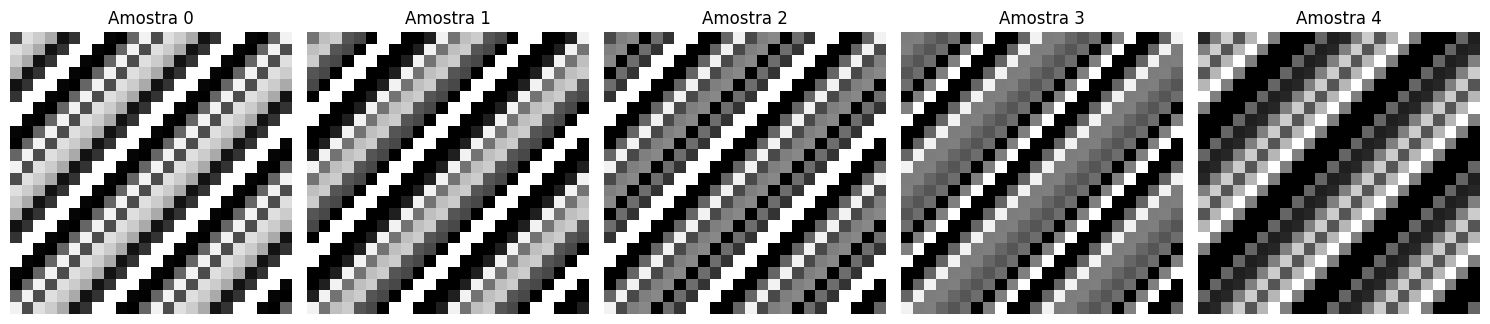

In [71]:
visualizar_imagens(datasets["adult income"]["X_images"], num_imagens=5)

## Treinamento

### GXboost

In [ ]:
X = datasets["adult income"]["X"]
y = datasets["adult income"]["y"]

def selecionar_linhas(dados, indices):
    return dados.iloc[indices] if hasattr(dados, "iloc") else dados[indices]

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resultados_xgb_folds = []
todos_alvos_xgb = []
todas_predicoes_xgb = []

print("Iniciando validação cruzada estratificada do XGBoost...")
print(f"Folds: {N_SPLITS}")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train = selecionar_linhas(X, train_idx)
    X_test = selecionar_linhas(X, test_idx)
    y_train = selecionar_linhas(y, train_idx)
    y_test = selecionar_linhas(y, test_idx)

    modelo_xgb = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
    )

    modelo_xgb.fit(X_train, y_train)
    y_pred = modelo_xgb.predict(X_test)
    acuracia = accuracy_score(y_test, y_pred)

    resultados_xgb_folds.append({"fold": fold, "accuracy": acuracia})
    todos_alvos_xgb.extend(np.asarray(y_test).tolist())
    todas_predicoes_xgb.extend(np.asarray(y_pred).tolist())

    print(f"Fold {fold}/{N_SPLITS} - acurácia: {acuracia * 100:.2f}%")

acuracias_xgb = np.array([resultado["accuracy"] for resultado in resultados_xgb_folds])
acuracia_media_xgb = acuracias_xgb.mean()
desvio_padrao_xgb = acuracias_xgb.std(ddof=1) if len(acuracias_xgb) > 1 else 0.0

print("\n" + "=" * 60)
print("RELATÓRIO TÉCNICO DE AVALIAÇÃO DO MODELO (XGBOOST - K-FOLD)")
print("=" * 60)
print(f"Acurácia média: {acuracia_media_xgb * 100:.2f}%")
print(f"Desvio padrão: {desvio_padrao_xgb * 100:.2f} p.p.")
print("Acurácias por fold: " + ", ".join(f"{acc * 100:.2f}%" for acc in acuracias_xgb))
print("-" * 60)
print(classification_report(todos_alvos_xgb, todas_predicoes_xgb, zero_division=0))
print("=" * 60)

resultado_xgb_kfold = {
    "model_name": "XGBoost",
    "folds": resultados_xgb_folds,
    "accuracy_mean": acuracia_media_xgb,
    "accuracy_std": desvio_padrao_xgb,
    "y_true": todos_alvos_xgb,
    "y_pred": todas_predicoes_xgb,
}


### NCTD

In [73]:
def adaptive_max_pool2d(x, output_size):
    out_h, out_w = output_size
    in_h, in_w = x.shape[1], x.shape[2]

    stride_h = max(1, in_h // out_h)
    stride_w = max(1, in_w // out_w)
    kernel_h = in_h - (out_h - 1) * stride_h
    kernel_w = in_w - (out_w - 1) * stride_w

    pool = mnn.MaxPool2d(
        kernel_size=(kernel_h, kernel_w),
        stride=(stride_h, stride_w),
        padding=0,
    )
    return pool(x)


class SEBlock(mnn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.fc1 = mnn.Linear(channels, hidden)
        self.fc2 = mnn.Linear(hidden, channels)

    def __call__(self, x):
        weights = mx.mean(x, axis=(1, 2))
        weights = mnn.relu(self.fc1(weights))
        weights = mx.sigmoid(self.fc2(weights))
        weights = mx.reshape(weights, (x.shape[0], 1, 1, x.shape[-1]))
        return x * weights


class ConvBlock(mnn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        stride,
        target_size,
        use_se=False,
        use_asymmetric=False,
        use_dilation=False,
        use_residual=False,
    ):
        super().__init__()
        self.target_size = target_size
        self.use_se = use_se
        self.use_asymmetric = use_asymmetric
        self.use_residual = use_residual

        dilation = 2 if use_dilation else 1
        padding = dilation

        if use_asymmetric:
            self.conv_a = mnn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=(1, 3),
                stride=(1, stride),
                padding=(0, padding),
                dilation=(1, dilation),
            )
            self.conv_b = mnn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=(3, 1),
                stride=(stride, 1),
                padding=(padding, 0),
                dilation=(dilation, 1),
            )
        else:
            self.conv = mnn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=padding,
                dilation=dilation,
            )

        self.bn = mnn.BatchNorm(out_channels)
        self.se = SEBlock(out_channels) if use_se else None

        needs_projection = use_residual and (in_channels != out_channels or stride != 1)
        self.proj = (
            mnn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
            if needs_projection
            else None
        )

    def __call__(self, x):
        shortcut = x

        if self.use_asymmetric:
            x = self.conv_a(x)
            x = mnn.relu(x)
            x = self.conv_b(x)
        else:
            x = self.conv(x)

        x = self.bn(x)
        x = mnn.relu(x)

        if self.se is not None:
            x = self.se(x)

        if self.use_residual:
            if self.proj is not None:
                shortcut = self.proj(shortcut)
            x = x + shortcut

        x = adaptive_max_pool2d(x, self.target_size)
        return x


class NCTD_CNN_Base(mnn.Module):
    def __init__(
        self,
        use_se=False,
        use_asymmetric=False,
        use_dilation=False,
        use_residual=False,
    ):
        super().__init__()

        self.block0 = ConvBlock(
            1,
            64,
            stride=1,
            target_size=(15, 15),
            use_se=use_se,
            use_asymmetric=use_asymmetric,
            use_dilation=False,
            use_residual=use_residual,
        )
        self.block1 = ConvBlock(
            64,
            64,
            stride=2,
            target_size=(7, 7),
            use_se=use_se,
            use_asymmetric=use_asymmetric,
            use_dilation=use_dilation,
            use_residual=use_residual,
        )
        self.block2 = ConvBlock(
            64,
            64,
            stride=2,
            target_size=(3, 3),
            use_se=use_se,
            use_asymmetric=use_asymmetric,
            use_dilation=use_dilation,
            use_residual=use_residual,
        )
        self.block3 = ConvBlock(
            64,
            64,
            stride=2,
            target_size=(1, 1),
            use_se=use_se,
            use_asymmetric=use_asymmetric,
            use_dilation=False,
            use_residual=use_residual,
        )

        self.fc = mnn.Linear(64, 32)
        self.out = mnn.Linear(32, 2)

    def __call__(self, x):
        x = self.block0(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = mx.mean(x, axis=(1, 2))
        x = mnn.relu(self.fc(x))
        x = self.out(x)
        return x


MODEL_NAME = "NCTD Base"
MODEL_CLASS = lambda: NCTD_CNN_Base()

In [ ]:
X_images_bruto = datasets["adult income"]["X_images"]

y_df = datasets["adult income"]["y"]
y_numeric = y_df.values if isinstance(y_df, pd.Series) else y_df
y_numeric = np.asarray(y_numeric, dtype=np.int32)

# MLX usa channels-last: (N, H, W, C)
X_images_mlx = np.expand_dims(X_images_bruto, axis=-1).astype(np.float32) / 255.0

BATCH_SIZE = 64
EPOCHS = 30

print(f"Dataset completo: {len(X_images_mlx)} amostras")
print(f"Folds: {N_SPLITS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Épocas por fold: {EPOCHS}")


def run_nctd_experiment(model_name, model_class, epochs=EPOCHS, n_splits=N_SPLITS):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    resultados_folds = []
    todas_predicoes = []
    todos_alvos = []

    print(f"\nModelo ativo: {model_name}")
    print(f"Validação cruzada estratificada com {n_splits} folds")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_images_mlx, y_numeric), start=1):
        X_train = X_images_mlx[train_idx]
        X_val = X_images_mlx[val_idx]
        y_train = y_numeric[train_idx]
        y_val = y_numeric[val_idx]

        num_batches_train = (len(X_train) + BATCH_SIZE - 1) // BATCH_SIZE
        num_batches_val = (len(X_val) + BATCH_SIZE - 1) // BATCH_SIZE
        total_steps = epochs * num_batches_train + num_batches_val

        model = model_class()
        mx.eval(model.parameters())

        optimizer = optim.Adam(learning_rate=0.0008)

        def loss_fn(model, x, y):
            logits = model(x)
            return mx.mean(mnn.losses.cross_entropy(logits, y))

        loss_and_grad_fn = mnn.value_and_grad(model, loss_fn)
        rng = np.random.default_rng(RANDOM_STATE + fold)

        print("\n" + "-" * 60)
        print(f"Fold {fold}/{n_splits}")
        print(f"Treino: {len(X_train)} amostras | Validação: {len(X_val)} amostras")
        print(f"Treinamento: {epochs} épocas × {num_batches_train} batches = {epochs * num_batches_train} iterações")
        print(f"Validação: {num_batches_val} iterações")

        with tqdm(total=total_steps, desc=f"{model_name} | fold {fold}", unit="iter") as pbar:
            for epoch in range(epochs):
                model.train()
                running_loss = 0.0

                perm = rng.permutation(len(X_train))

                for start in range(0, len(X_train), BATCH_SIZE):
                    end = min(start + BATCH_SIZE, len(X_train))
                    idx = perm[start:end]

                    batch_x = mx.array(X_train[idx])
                    batch_y = mx.array(y_train[idx])

                    loss, grads = loss_and_grad_fn(model, batch_x, batch_y)
                    optimizer.update(model, grads)
                    mx.eval(model.parameters(), optimizer.state)

                    loss_val = loss.item()
                    running_loss += loss_val * len(idx)

                    pbar.update(1)
                    pbar.set_postfix({
                        "epoch": f"{epoch + 1}/{epochs}",
                        "loss": f"{loss_val:.4f}",
                    })

                epoch_loss = running_loss / len(X_train)
                pbar.set_postfix({
                    "epoch": f"{epoch + 1}/{epochs} finalizada",
                    "loss": f"{epoch_loss:.4f}",
                })

            model.eval()
            predicoes_fold = []
            alvos_fold = []

            for start in range(0, len(X_val), BATCH_SIZE):
                end = min(start + BATCH_SIZE, len(X_val))
                batch_x = mx.array(X_val[start:end])

                logits = model(batch_x)
                preds = mx.argmax(logits, axis=1)
                mx.eval(preds)

                predicoes_fold.extend(np.array(preds).tolist())
                alvos_fold.extend(y_val[start:end].tolist())

                pbar.update(1)
                pbar.set_postfix({"fase": "validação"})

            pbar.set_postfix({"fase": "concluído"})

        acuracia_fold = accuracy_score(alvos_fold, predicoes_fold)
        resultados_folds.append({"fold": fold, "accuracy": acuracia_fold})
        todos_alvos.extend(alvos_fold)
        todas_predicoes.extend(predicoes_fold)

        print(f"Acurácia do fold {fold}: {acuracia_fold * 100:.2f}%")

    acuracias = np.array([resultado["accuracy"] for resultado in resultados_folds])
    acuracia_media = acuracias.mean()
    desvio_padrao = acuracias.std(ddof=1) if len(acuracias) > 1 else 0.0

    print("\n" + "=" * 60)
    print(f"RELATÓRIO TÉCNICO DE AVALIAÇÃO DA CNN ({model_name} - K-FOLD)")
    print("=" * 60)
    print(f"Acurácia média nas imagens 2N: {acuracia_media * 100:.2f}%")
    print(f"Desvio padrão: {desvio_padrao * 100:.2f} p.p.")
    print("Acurácias por fold: " + ", ".join(f"{acc * 100:.2f}%" for acc in acuracias))
    print("-" * 60)
    print(classification_report(todos_alvos, todas_predicoes, zero_division=0))
    print("=" * 60)

    return {
        "model_name": model_name,
        "folds": resultados_folds,
        "accuracy_mean": acuracia_media,
        "accuracy_std": desvio_padrao,
        "y_true": todos_alvos,
        "y_pred": todas_predicoes,
    }


In [75]:
MODEL_NAME = "NCTD Attention (SE)"
MODEL_CLASS = lambda: NCTD_CNN_Base(use_se=True)
print(f"Modelo selecionado: {MODEL_NAME}")

Modelo selecionado: NCTD Attention (SE)


In [76]:
resultado_attention = run_nctd_experiment(
    "NCTD Attention (SE)",
    lambda: NCTD_CNN_Base(use_se=True),
)


Modelo ativo: NCTD Attention (SE)
Treinamento: 30 épocas × 611 batches = 18330 iterações
Validação: 153 iterações
Total: 18483 iterações



NCTD Attention (SE): 100%|██████████| 18483/18483 [07:11<00:00, 42.81iter/s, fase=concluído]                     



RELATÓRIO TÉCNICO DE AVALIAÇÃO DA CNN (NCTD Attention (SE))
Acurácia Geral do Modelo nas Imagens 2N: 84.99%
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      7431
           1       0.71      0.62      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.80      0.77      0.78      9769
weighted avg       0.84      0.85      0.85      9769



#### Variante 1 — Attention (SE)

In [77]:
MODEL_NAME = "NCTD Asymmetric Kernels"
MODEL_CLASS = lambda: NCTD_CNN_Base(use_asymmetric=True)
print(f"Modelo selecionado: {MODEL_NAME}")

Modelo selecionado: NCTD Asymmetric Kernels


In [78]:
resultado_asymmetric = run_nctd_experiment(
    "NCTD Asymmetric Kernels",
    lambda: NCTD_CNN_Base(use_asymmetric=True),
)


Modelo ativo: NCTD Asymmetric Kernels
Treinamento: 30 épocas × 611 batches = 18330 iterações
Validação: 153 iterações
Total: 18483 iterações



NCTD Asymmetric Kernels: 100%|██████████| 18483/18483 [07:18<00:00, 42.17iter/s, fase=concluído]                     



RELATÓRIO TÉCNICO DE AVALIAÇÃO DA CNN (NCTD Asymmetric Kernels)
Acurácia Geral do Modelo nas Imagens 2N: 85.09%
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      7431
           1       0.79      0.52      0.62      2338

    accuracy                           0.85      9769
   macro avg       0.82      0.74      0.77      9769
weighted avg       0.84      0.85      0.84      9769



#### Variante 2 — Kernels Assimétricos

In [79]:
MODEL_NAME = "NCTD Dilated Convolutions"
MODEL_CLASS = lambda: NCTD_CNN_Base(use_dilation=True)
print(f"Modelo selecionado: {MODEL_NAME}")

Modelo selecionado: NCTD Dilated Convolutions


In [80]:
resultado_dilated = run_nctd_experiment(
    "NCTD Dilated Convolutions",
    lambda: NCTD_CNN_Base(use_dilation=True),
)


Modelo ativo: NCTD Dilated Convolutions
Treinamento: 30 épocas × 611 batches = 18330 iterações
Validação: 153 iterações
Total: 18483 iterações



NCTD Dilated Convolutions: 100%|██████████| 18483/18483 [06:37<00:00, 46.46iter/s, fase=concluído]                     



RELATÓRIO TÉCNICO DE AVALIAÇÃO DA CNN (NCTD Dilated Convolutions)
Acurácia Geral do Modelo nas Imagens 2N: 84.40%
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      7431
           1       0.67      0.69      0.68      2338

    accuracy                           0.84      9769
   macro avg       0.79      0.79      0.79      9769
weighted avg       0.85      0.84      0.84      9769



#### Variante 3 — Convoluções Dilatadas

In [81]:
MODEL_NAME = "NCTD Residual"
MODEL_CLASS = lambda: NCTD_CNN_Base(use_residual=True)
print(f"Modelo selecionado: {MODEL_NAME}")

Modelo selecionado: NCTD Residual


In [82]:
resultado_residual = run_nctd_experiment(
    "NCTD Residual",
    lambda: NCTD_CNN_Base(use_residual=True),
)


Modelo ativo: NCTD Residual
Treinamento: 30 épocas × 611 batches = 18330 iterações
Validação: 153 iterações
Total: 18483 iterações



NCTD Residual: 100%|██████████| 18483/18483 [07:01<00:00, 43.81iter/s, fase=concluído]                     



RELATÓRIO TÉCNICO DE AVALIAÇÃO DA CNN (NCTD Residual)
Acurácia Geral do Modelo nas Imagens 2N: 84.84%
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      7431
           1       0.78      0.51      0.62      2338

    accuracy                           0.85      9769
   macro avg       0.82      0.73      0.76      9769
weighted avg       0.84      0.85      0.84      9769



#### Variante 4 — Conexões Residuais

In [83]:
MODEL_NAME = "NCTD Base"
MODEL_CLASS = lambda: NCTD_CNN_Base()
print(f"Modelo selecionado: {MODEL_NAME}")

Modelo selecionado: NCTD Base


In [84]:
resultado_base = run_nctd_experiment(
    "NCTD Base",
    lambda: NCTD_CNN_Base(),
)


Modelo ativo: NCTD Base
Treinamento: 30 épocas × 611 batches = 18330 iterações
Validação: 153 iterações
Total: 18483 iterações



NCTD Base: 100%|██████████| 18483/18483 [06:37<00:00, 46.53iter/s, fase=concluído]                     



RELATÓRIO TÉCNICO DE AVALIAÇÃO DA CNN (NCTD Base)
Acurácia Geral do Modelo nas Imagens 2N: 84.98%
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.94      0.91      7431
           1       0.75      0.55      0.64      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.75      0.77      9769
weighted avg       0.84      0.85      0.84      9769



#### Baseline — NCTD Base